# Construcción del dataset de ground truth — descarga y selección de estaciones

Esta notebook continúa el trabajo de `01-ground_truth_exploration.ipynb`, que determinó que 2024-2025 son los años con cobertura suficiente para ground truth, dejando como candidatas las 70 estaciones con datos en al menos uno de los dos años.

A partir de ahí, esta notebook: (1) descarga los registros de precipitación sub-horaria de esas 70 estaciones desde [`s54a-sgyg`](https://www.datos.gov.co/Ambiente-y-Desarrollo-Sostenible/Precipitaci-n/s54a-sgyg/about_data), y (2) aplica un primer filtro de selección por cobertura temporal y densidad de registros, para excluir estaciones con datos insuficientes o gaps de transmisión severos.

**Resultado de esta notebook:** 66 estaciones seleccionadas, guardadas en `estaciones_ground_truth.csv`. El control de calidad más profundo sobre esas 66 (metadatos, precisión decimal, homogeneidad, criterios de exclusión) se hace en `03-ground_truth_qc.ipynb`.

In [1]:
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

import os
import time
from datetime import datetime

## 1. Descarga

Los datos se descargan del dataset `s54a-sgyg` para las 70 estaciones seleccionadas en 2024 y 2025. El script descarga mes a mes por estación, guarda un log de combinaciones completadas para reanudar si se interrumpe, y almacena un CSV por estación en `data/rainfall_subhourly/`.

**Nota:** si los CSVs ya existen en `data/rainfall_subhourly/`, esta sección no necesita correrse de nuevo. Pasar directamente a la sección 2.

In [ ]:
# Descarga de los datos
URL_PRECIP = "https://www.datos.gov.co/resource/s54a-sgyg.json"
AÑOS = [2024, 2025]
MESES = range(1, 13)
PAUSA = 0.5  # segundos entre consultas
REINTENTOS = 3
LOG_FILE = "descarga_precipitacion_log.txt"
OUTPUT_DIR = r"..\..\data\rainfall_subhourly_raw"

# Crear carpeta de salida
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Cargar log de combinaciones ya completadas
completados = set()
if os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'r') as f:
        completados = set(line.strip() for line in f.readlines())
print(f"Combinaciones ya completadas: {len(completados)}")

# Cargar estaciones objetivo
df_anual = pd.read_csv('precipitacion_anual_candidatas.csv', dtype={'codigoestacion': str})
est_2024 = set(df_anual[df_anual['anio'] == 2024]['codigoestacion'])
est_2025 = set(df_anual[df_anual['anio'] == 2025]['codigoestacion'])
estaciones_objetivo = est_2024 | est_2025
print(f"Estaciones objetivo: {len(estaciones_objetivo)}")

# Función de descarga con reintentos
def descargar_mes(cod, año, mes):
    fecha_ini = f"{año}-{mes:02d}-01T00:00:00"
    if mes == 12:
        fecha_fin = f"{año}-12-31T23:59:59"
    else:
        fecha_fin = f"{año}-{mes+1:02d}-01T00:00:00"
    
    for intento in range(REINTENTOS):
        try:
            params = {
                "$where": f"codigoestacion='{cod}' AND fechaobservacion >= '{fecha_ini}' AND fechaobservacion < '{fecha_fin}'",
                "$order": "fechaobservacion ASC",
                "$limit": 50000
            }
            r = requests.get(URL_PRECIP, params=params, timeout=60)
            data = r.json()
            if isinstance(data, list):
                return data
        except Exception as e:
            print(f"  Intento {intento+1}/{REINTENTOS} fallido: {e}")
            time.sleep(2 ** intento)  # espera exponencial: 1, 2, 4 segundos
    return None

# Descarga principal
total = len(estaciones_objetivo) * len(AÑOS) * len(list(MESES))
procesados = 0

for cod in sorted(estaciones_objetivo):
    registros_estacion = []
    
    for año in AÑOS:
        # Solo descargar si la estación tiene datos ese año
        if año == 2024 and cod not in est_2024:
            continue
        if año == 2025 and cod not in est_2025:
            continue
        
        for mes in MESES:
            key = f"{cod}_{año}_{mes:02d}"
            procesados += 1
            
            if key in completados:
                print(f"[{procesados}/{total}] Ya completado: {key}")
                continue
            
            print(f"[{procesados}/{total}] Descargando: {key}...")
            data = descargar_mes(cod, año, mes)
            
            if data is None:
                print(f"  ERROR: no se pudo descargar {key} después de {REINTENTOS} intentos")
                continue
            
            if len(data) > 0:
                registros_estacion.extend(data)
                print(f"  OK: {len(data)} registros")
            else:
                print(f"  Sin datos")
            
            # Registrar en log
            with open(LOG_FILE, 'a') as f:
                f.write(key + '\n')
            
            time.sleep(PAUSA)
    
    # Guardar CSV por estación
    if registros_estacion:
        df_est = pd.DataFrame(registros_estacion)
        df_est = df_est[['codigoestacion', 'fechaobservacion', 'valorobservado']]
        df_est.to_csv(f"{OUTPUT_DIR}/{cod}.csv", index=False)
        print(f"  Guardado: {OUTPUT_DIR}/{cod}.csv ({len(df_est)} registros)")

print("\nDescarga completada.")

### 1.1 Verificación de la descarga

Como verificación de la descarga, se examinan los registros de la estación `0021201980 (Cerro Guadalupe)`, que sirve de referencia por haber sido validada previamente contra la visualización oficial del portal datos.gov.co.

La precipitación total anual es similar en ambos años (~564 mm en 2024 y ~552 mm en 2025), consistente con los totales reportados por la fuente original. La serie diaria muestra el patrón climatológico esperado para la Sabana de Bogotá: temporada seca en el primer semestre de 2024 (enero-agosto, coincidente con el final del episodio El Niño), un pico de actividad convectiva en el último trimestre de 2024 con un evento extremo de ~170 mm el 4 de noviembre, y una distribución más uniforme a lo largo de 2025. La descarga se considera verificada.

   anio  valorobservado
0  2024           564.1
1  2025           552.8


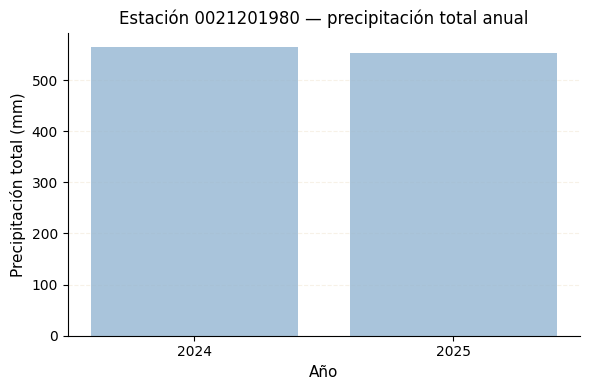

In [ ]:
# Verificación de la descarga contra estación 0021201980, Cerro Guadalupe
df_test = pd.read_csv(r'..\..\data\rainfall_subhourly\0021201980.csv')  #  
df_test['fechaobservacion'] = pd.to_datetime(df_test['fechaobservacion'])
df_test['anio'] = df_test['fechaobservacion'].dt.year
df_test['valorobservado'] = pd.to_numeric(df_test['valorobservado'])

precip_anual = df_test.groupby('anio')['valorobservado'].sum().reset_index()
print(precip_anual)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(precip_anual['anio'], precip_anual['valorobservado'], color='#94B6D2', alpha=0.8)
ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Precipitación total (mm)', fontsize=11)
ax.set_title('Estación 0021201980 — precipitación total anual', fontsize=12)
ax.set_xticks([2024, 2025])
plt.tight_layout()
plt.show()

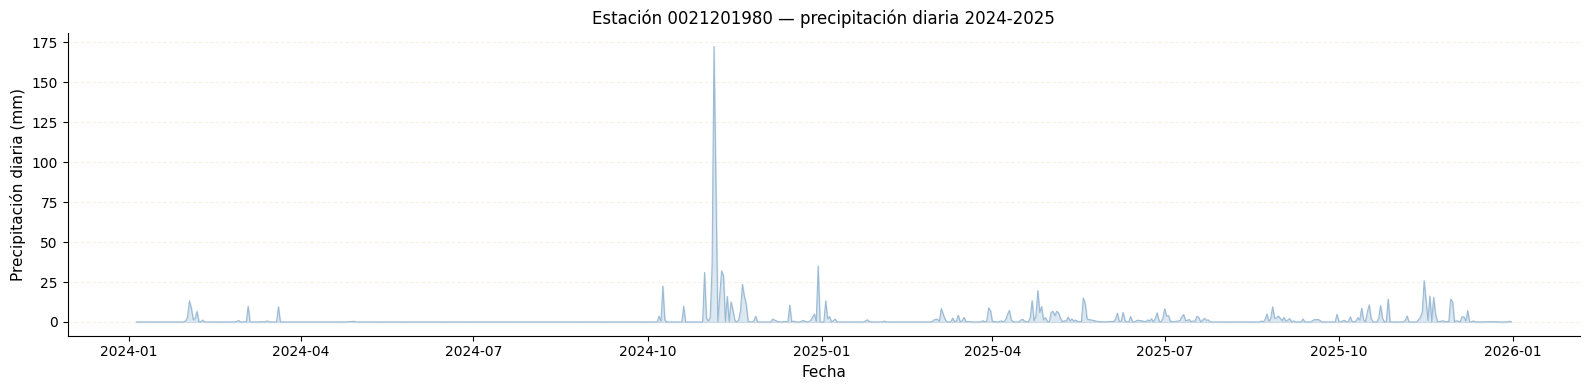

In [ ]:
#Visualización de precipitación acumulada diaria de estación 0021201980
precip_diaria = df_test.groupby(df_test['fechaobservacion'].dt.date)['valorobservado'].sum().reset_index()
precip_diaria.columns = ['fecha', 'precip_mm']
precip_diaria['fecha'] = pd.to_datetime(precip_diaria['fecha'])

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(precip_diaria['fecha'], precip_diaria['precip_mm'], 
        color='#94B6D2', linewidth=0.8, alpha=0.9)
ax.fill_between(precip_diaria['fecha'], precip_diaria['precip_mm'], 
                alpha=0.3, color='#94B6D2')
ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Precipitación diaria (mm)', fontsize=11)
ax.set_title('Estación 0021201980 — precipitación diaria 2024-2025', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Selección de estaciones

De las 70 estaciones descargadas, no todas tienen cobertura temporal suficiente para ser útiles en el entrenamiento y validación del modelo. Se aplica un control de calidad en dos pasos: primero, se evalúa la cobertura temporal de cada estación medida como el rango entre el primer y el último registro disponible; segundo, se evalúa la densidad de registros en ese período para detectar estaciones con transmisión irregular o gaps significativos.

In [2]:
# Ver tamaño de cada CSV
resumen_csvs = []
for archivo in sorted(os.listdir(r'..\..\data\rainfall_subhourly')):
    if archivo.endswith('.csv'):
        df = pd.read_csv(r'..\..\data\rainfall_subhourly\\' + archivo, 
                         dtype={'codigoestacion': str})
        resumen_csvs.append({
            'estacion': archivo.replace('.csv', ''),
            'n_registros': len(df),
            'fecha_min': df['fechaobservacion'].min(),
            'fecha_max': df['fechaobservacion'].max()
        })

df_resumen = pd.DataFrame(resumen_csvs)
print(df_resumen.sort_values('n_registros').to_string())

      estacion  n_registros                fecha_min                fecha_max
20  0021206990          268  2024-09-04T00:00:00.000  2024-09-13T03:30:00.000
19  0021206980        31417  2025-05-16T00:00:00.000  2025-12-31T23:50:00.000
9   0021205700        32102  2024-10-29T02:10:00.000  2025-12-31T23:50:00.000
22  0035025060        42616  2024-10-29T02:10:00.000  2025-12-31T23:50:00.000
8   0021205420        52827  2024-10-29T03:00:00.000  2025-12-31T23:50:00.000
13  0021206280        54617  2024-09-04T00:00:00.000  2025-12-31T23:50:00.000
69  2306500204        54752  2024-10-29T02:10:00.000  2025-12-31T23:50:00.000
12  0021205910        55121  2024-09-04T00:00:00.000  2025-12-31T23:50:00.000
7   0021205012        55812  2024-09-04T00:00:00.000  2025-12-31T23:50:00.000
64  2120500135        55881  2024-09-04T00:20:00.000  2025-12-31T23:50:00.000
10  0021205710        56002  2024-09-04T00:00:00.000  2025-12-31T23:50:00.000
14  0021206560        56292  2024-07-07T00:00:00.000  2025-12-31

### 2.1 Cobertura temporal

El análisis revela dos grupos claramente diferenciados. Un primer grupo de 53 estaciones tiene cobertura de al menos 23 meses (enero 2024 a diciembre 2025), con conteos superiores a 350,000 registros. Un segundo grupo de 17 estaciones tiene cobertura parcial, con inicio entre abril de 2024 y octubre de 2025, y finalización en su mayoría en diciembre de 2025.

Dentro del grupo de cobertura parcial se aplican los siguientes criterios de exclusión:

- **Cobertura inferior a 6 meses o densidad de registros insuficiente:** se excluyen las estaciones `0021206990` (268 registros, 10 días en septiembre 2024), `2120000104` (71,486 registros, octubre-diciembre 2025) y `0021206980` (31,417 registros, mayo-diciembre 2025). Las dos primeras no capturan ningún ciclo estacional completo; la tercera, aunque tiene 7 meses de datos, presenta una densidad de registros inferior a la mitad de lo esperado para ese período, lo que indica gaps significativos en la transmisión.

- **Cobertura entre 12 y 22 meses:** las 14 estaciones restantes serán evaluadas en la siguiente sección mediante su densidad de registros. Si la densidad es suficiente, se conservan como candidatas al conjunto de prueba, dado que su inicio tardío en 2024 limita su utilidad para el entrenamiento pero no para la evaluación.

Estaciones con cobertura parcial (<23 meses): 17


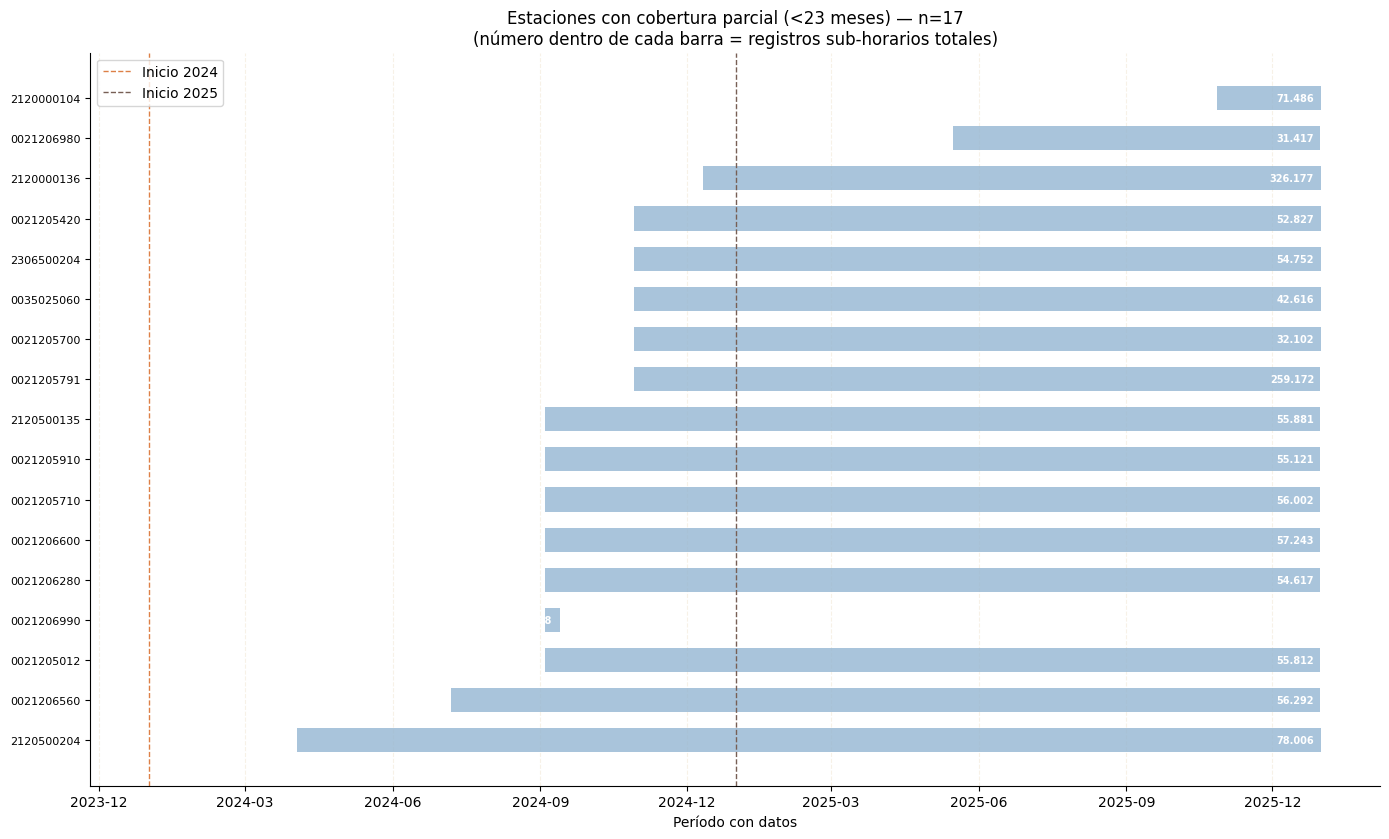

In [3]:
# Registros subhorarios para estaciones con cubrimiento menor a 24 meses
df_resumen['fecha_min'] = pd.to_datetime(df_resumen['fecha_min'])
df_resumen['fecha_max'] = pd.to_datetime(df_resumen['fecha_max'])
df_resumen['duracion_meses'] = ((df_resumen['fecha_max'] - df_resumen['fecha_min']).dt.days / 30.44).round(1)

# Solo estaciones con menos de 24 meses
df_plot_parcial = df_resumen[df_resumen['duracion_meses'] < 23].sort_values('fecha_min').reset_index(drop=True)
print(f"Estaciones con cobertura parcial (<23 meses): {len(df_plot_parcial)}")

fig, ax = plt.subplots(figsize=(14, max(6, len(df_plot_parcial) * 0.5)))

for i, row in df_plot_parcial.iterrows():
    duracion = (row['fecha_max'] - row['fecha_min']).days
    ax.barh(i, duracion, left=row['fecha_min'], height=0.6,
            color='#94B6D2', alpha=0.8)
    
    ax.text(row['fecha_max'] - pd.Timedelta(days=5), i,
            f"{row['n_registros']:,}".replace(',', '.'),
            va='center', ha='right', fontsize=7, color='white',
            fontweight='bold')

ax.axvline(pd.Timestamp('2024-01-01'), color='#DD8047', linestyle='--', linewidth=1, label='Inicio 2024')
ax.axvline(pd.Timestamp('2025-01-01'), color='#775F55', linestyle='--', linewidth=1, label='Inicio 2025')

ax.set_yticks(range(len(df_plot_parcial)))
ax.set_yticklabels(df_plot_parcial['estacion'], fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.set_xlabel('Período con datos')
ax.set_title(f'Estaciones con cobertura parcial (<23 meses) — n={len(df_plot_parcial)}\n(número dentro de cada barra = registros sub-horarios totales)',
             fontsize=12)
ax.legend()
ax.yaxis.grid(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 2.2 Densidad de registros

La cobertura temporal no es suficiente por sí sola para garantizar la calidad de una estación: una estación puede tener un rango temporal amplio pero con gaps internos que reduzcan significativamente la información disponible. Para las 14 estaciones con cobertura parcial que superaron el filtro anterior, se calcula la densidad de registros, definida como el cociente entre los registros reales y los esperados según la cadencia de transmisión de cada estación.

**Densidad por cobertura de referencia:** se compara el número de registros reales contra los esperados si la estación hubiera transmitido con la misma frecuencia mediana que las estaciones con cobertura completa (~731 registros por día). Este primer análisis muestra que 12 de las 14 estaciones tienen densidades entre 12% y 21% — aparentemente muy bajas. Sin embargo, antes de excluirlas, se investiga la cadencia real de transmisión de cada estación.

**Densidad por cadencia real:** la cadencia mediana varía entre estaciones. La mayoría transmite cada 10 minutos; `0021205791` lo hace cada 2.2 minutos en promedio, y `2120000136` cada 1.3 minutos. Al recalcular los registros esperados usando la cadencia propia de cada estación, las densidades se reinterpretan: ocho estaciones alcanzan entre 80% y 93%, consistentes con su propia frecuencia de transmisión. Las seis restantes quedan por debajo de ese umbral y se examinan con mayor detalle:

| estación | densidad_cadencia_pct |
|---|---|
| `0021205700` | 52.1% |
| `0035025060` | 69.1% |
| `0021206560` | 72.1% |
| `2120000136` | 76.5% |
| `0021206280` | 78.5% |
| `0021205910` | 79.3% |

In [4]:
# Estaciones con cobertura parcial (excluidas las 3 ya descartadas)
excluir = ['0021206990', '2120000104', '0021206980']
df_parcial = df_resumen[
    (df_resumen['duracion_meses'] < 23) & 
    (~df_resumen['estacion'].isin(excluir))
].copy()

# Días de cobertura
df_parcial['dias_cobertura'] = (df_parcial['fecha_max'] - df_parcial['fecha_min']).dt.days

# Registros esperados según referencia de estaciones completas
registros_por_dia_referencia = df_resumen[df_resumen['duracion_meses'] >= 23]['n_registros'].median() / (24 * 30.44)
df_parcial['reg_esp_cobertura'] = (df_parcial['dias_cobertura'] * registros_por_dia_referencia).astype(int)
df_parcial['densidad_cobertura_pct'] = (df_parcial['n_registros'] / df_parcial['reg_esp_cobertura'] * 100).round(1)

# Cadencia real por estación
def estadisticas_cadencia(cod):
    try:
        df = pd.read_csv(f'..\\..\\data\\rainfall_subhourly\\{cod}.csv')
        df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])
        df = df.sort_values('fechaobservacion')
        intervalos = df['fechaobservacion'].diff().dt.total_seconds() / 60
        intervalos = intervalos[(intervalos > 0) & (intervalos <= 60)]  # excluir outliers
        return intervalos.min(), intervalos.max(), intervalos.mean().round(1)
    except:
        return None, None, None

df_parcial[['cadencia_min', 'cadencia_max', 'cadencia_prom']] = df_parcial['estacion'].apply(
    lambda cod: pd.Series(estadisticas_cadencia(cod))
)

# Registros esperados según cadencia real
df_parcial['reg_esp_cadencia'] = (
    df_parcial['dias_cobertura'] * 24 * 60 / df_parcial['cadencia_prom']
).astype(int)
df_parcial['densidad_cadencia_pct'] = (
    df_parcial['n_registros'] / df_parcial['reg_esp_cadencia'] * 100
).round(1)

# Tabla final
cols = ['estacion', 'duracion_meses', 'n_registros', 
        'reg_esp_cobertura', 'densidad_cobertura_pct',
        'cadencia_min', 'cadencia_max', 'cadencia_prom',
        'reg_esp_cadencia', 'densidad_cadencia_pct']

df_parcial[cols].sort_values('densidad_cadencia_pct')

,estacion,duracion_meses,n_registros,reg_esp_cobertura,densidad_cobertura_pct,cadencia_min,cadencia_max,cadencia_prom,reg_esp_cadencia,densidad_cadencia_pct
9,0021205700,14.1,32102,258241,12.4,10.0,60.0,10.0,61632,52.1
22,0035025060,14.1,42616,258241,16.5,10.0,60.0,10.0,61632,69.1
14,0021206560,17.8,56292,327025,17.2,10.0,60.0,10.0,78048,72.1
52,2120000136,12.6,326177,232296,140.4,1.0,58.0,1.3,426461,76.5
13,0021206280,15.9,54617,291426,18.7,10.0,50.0,10.0,69552,78.5
12,0021205910,15.9,55121,291426,18.9,10.0,40.0,10.0,69552,79.3
7,0021205012,15.9,55812,291426,19.2,10.0,40.0,10.0,69552,80.2
64,2120500135,15.9,55881,291426,19.2,10.0,30.0,10.0,69552,80.3
10,0021205710,15.9,56002,291426,19.2,10.0,40.0,10.0,69552,80.5
15,0021206600,15.9,57243,291426,19.6,1.0,60.0,10.1,68863,83.1


**Inspección de gaps:** para estas seis estaciones se inspecciona visualmente la serie de registros diarios y se cuantifica la racha máxima de días consecutivos sin transmisión (umbral: menos del 20% de los registros esperados según la cadencia propia de cada estación).

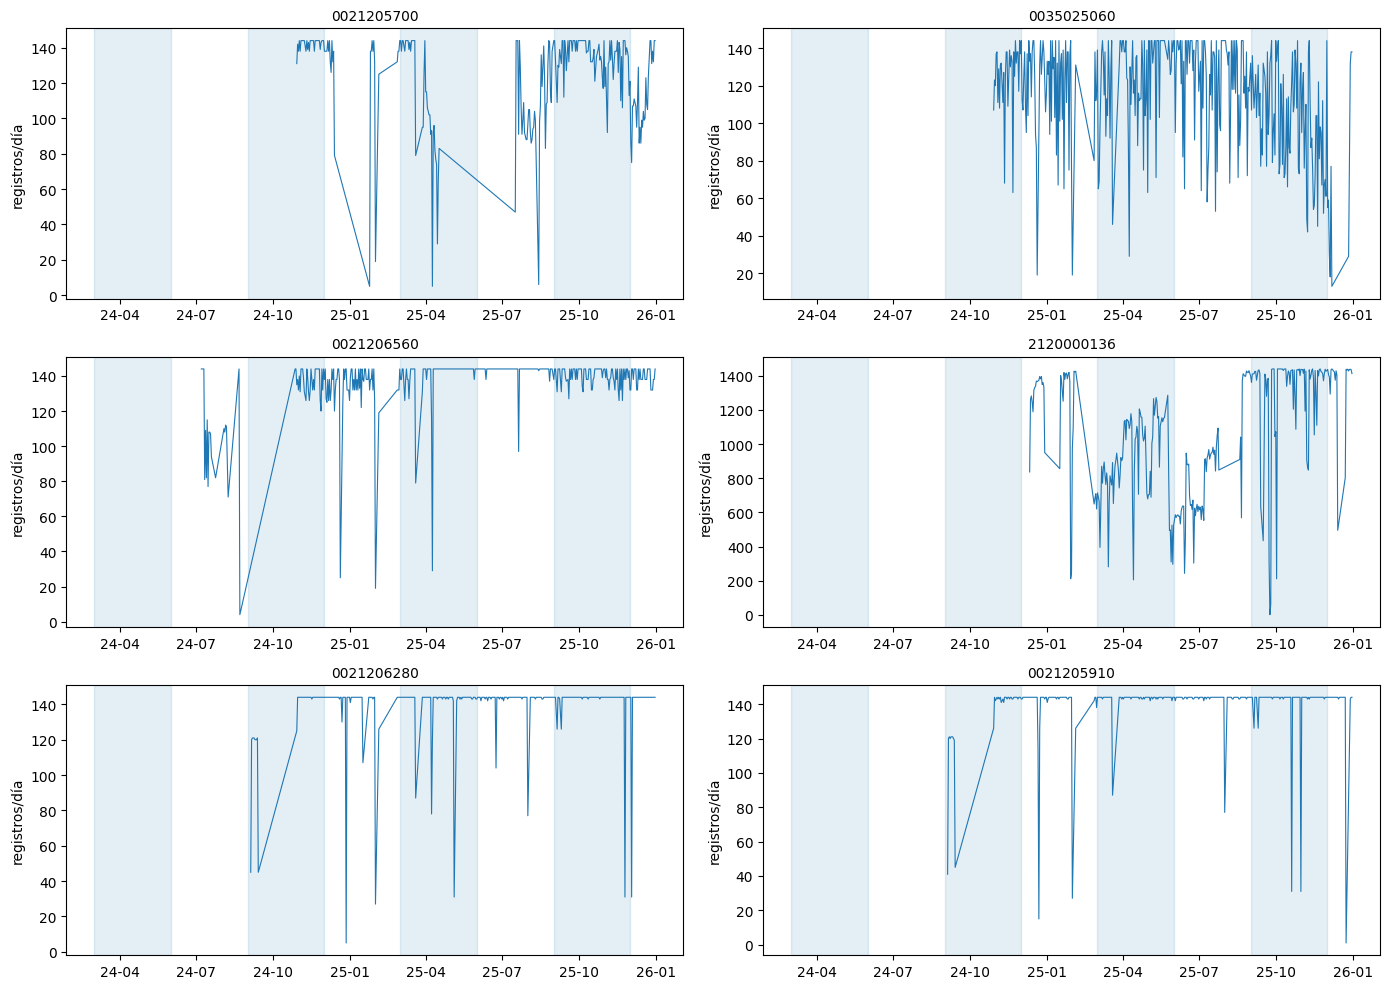

In [5]:
# Registros diarios de las seis estaciones con una cobertura de cadencia porcentual menor a 80%
BANDAS_HUMEDAS = {
    'MAM_24': ('2024-03-01', '2024-06-01'),
    'SON_24': ('2024-09-01', '2024-12-01'),
    'MAM_25': ('2025-03-01', '2025-06-01'),
    'SON_25': ('2025-09-01', '2025-12-01'),
}

estaciones_revisar = ['0021205700', '0035025060', '0021206560', '2120000136', '0021206280', '0021205910']

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for ax, cod in zip(axes.flat, estaciones_revisar):
    df = pd.read_csv(f'..\\..\\data\\rainfall_subhourly\\{cod}.csv')
    df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])

    registros_diarios = df.groupby(df['fechaobservacion'].dt.date).size()
    registros_diarios.index = pd.to_datetime(registros_diarios.index)

    ax.plot(registros_diarios.index, registros_diarios.values, linewidth=0.8)

    for ini, fin in BANDAS_HUMEDAS.values():
        ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color='tab:blue', alpha=0.12, zorder=0)

    ax.set_title(cod, fontsize=10)
    ax.set_ylabel('registros/día')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
    ax.tick_params(axis='x')

plt.tight_layout()
plt.show()

In [6]:
def analizar_gaps(cod, umbral_pct=20):
    df = pd.read_csv(f'..\\..\\data\\rainfall_subhourly\\{cod}.csv')
    df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])

    # Cadencia propia de la estación, para fijar el umbral de "día con gap" en su propia escala
    intervalos = df.sort_values('fechaobservacion')['fechaobservacion'].diff().dt.total_seconds() / 60
    cadencia_prom = intervalos[(intervalos > 0) & (intervalos <= 60)].mean()
    esperados_dia = 24 * 60 / cadencia_prom

    registros_diarios = df.groupby(df['fechaobservacion'].dt.date).size()
    registros_diarios.index = pd.to_datetime(registros_diarios.index)

    # Reindexar al rango diario completo: los días sin ninguna fila deben contar como 0, no desaparecer
    rango_completo = pd.date_range(registros_diarios.index.min(), registros_diarios.index.max(), freq='D')
    registros_diarios = registros_diarios.reindex(rango_completo, fill_value=0)

    es_gap = registros_diarios < (esperados_dia * umbral_pct / 100)
    n_dias_gap = int(es_gap.sum())
    pct_dias_gap = round(n_dias_gap / len(registros_diarios) * 100, 1)

    resultado = {
        'estacion': cod,
        'dias_totales': len(registros_diarios),
        'dias_con_gap': n_dias_gap,
        'pct_dias_con_gap': pct_dias_gap,
        'racha_maxima_dias': 0,
        'racha_inicio': None,
        'racha_fin': None,
    }

    if n_dias_gap > 0:
        # Racha máxima de días consecutivos en gap: distingue "disperso" de "prolongado"
        grupo = (es_gap != es_gap.shift()).cumsum()
        rachas = registros_diarios[es_gap].groupby(grupo[es_gap]).size()
        id_racha_max = rachas.idxmax()
        fechas_racha = registros_diarios[es_gap][grupo[es_gap] == id_racha_max].index

        resultado['racha_maxima_dias'] = len(fechas_racha)
        resultado['racha_inicio'] = fechas_racha.min().date()
        resultado['racha_fin'] = fechas_racha.max().date()

    return resultado


estaciones_revisar = ['0021205700', '0035025060', '0021206560', '2120000136', '0021206280', '0021205910']
resumen_gaps = pd.DataFrame([analizar_gaps(cod) for cod in estaciones_revisar])
resumen_gaps.sort_values('racha_maxima_dias', ascending=False)

,estacion,dias_totales,dias_con_gap,pct_dias_con_gap,racha_maxima_dias,racha_inicio,racha_fin
0,0021205700,429,175,40.8,90,2025-04-18,2025-07-16
2,0021206560,543,137,25.2,66,2024-08-22,2024-10-26
5,0021205910,484,95,19.6,45,2024-09-14,2024-10-28
4,0021206280,484,97,20.0,45,2024-09-14,2024-10-28
3,2120000136,386,86,22.3,24,2025-07-26,2025-08-18
1,0035025060,429,66,15.4,21,2025-02-05,2025-02-25


Solo `0021205700` presenta un patrón de gaps prolongados y sistemáticos: la inspección visual confirma tramos extensos sin transmisión, con una racha máxima de 90 días consecutivos que cae dentro de MAM_25. **Se excluye.**

Las otras cinco muestran gaps cortos y dispersos, o rachas moderadas concentradas en ventanas puntuales. **Se conservan**, con una observación que se documenta como limitación:

`0021206560`, `0021205910` y `0021206280` tienen su racha más larga (45-66 días) concentrada entre agosto y octubre de 2024, dentro de la temporada SON_24. Esto reduce la densidad de señal de estas tres estaciones durante esa temporada específica en el período de entrenamiento, sin descalificarlas del dataset. Llama la atención que `0021205910` y `0021206280` comparten exactamente el mismo rango de fechas (14 de septiembre a 28 de octubre de 2024), lo que sugiere una interrupción de transmisión compartida — posiblemente de red o del proveedor — más que una falla independiente de cada estación. Esta ventana coincide además, de forma parcial, con el período de mayor concentración de registros duplicados a nivel de red (octubre 2024), lo que abre la hipótesis, no verificada, de un problema de transmisión común en ese período.

`2120000136` y `0035025060` tienen gaps más cortos (21-24 días) ubicados en temporadas de transición (JJA_25 y DEF_25) que no forman parte de la comparación de temporadas húmedas de este trabajo, por lo que no representan un riesgo adicional.

**Resultado del análisis *2.2 Densidad de Registros*** de las 14 estaciones con cobertura parcial, se excluye únicamente `0021205700` por presentar gaps prolongados y sistemáticos que comprometen su utilidad tanto para entrenamiento como para prueba. Las 13 estaciones restantes se conservan, con la salvedad documentada de que tres de ellas (`0021206560`, `0021205910`, `0021206280`) tienen una ventana de datos reducida durante SON_24, registrada como limitación del dataset y no como criterio de exclusión.

## Conclusiones

Según los resultados de esta sección, se identifican **4 estaciones** que deben ser excluídas del dataset final:

| Estación | Motivo de exclusión |
|----------|-------------------|
| `0021206990` | 10 días de datos (268 registros), sin representatividad estacional |
| `2120000104` | 2 meses de datos (oct-dic 2025), fuera del período de entrenamiento |
| `0021206980` | 7 meses con baja densidad de registros (31,417 registros) |
| `0021205700` | Gaps severos y sistemáticos (densidad real 52.1%) |

El dataset final de ground truth queda compuesto por **66 estaciones**.

In [7]:
# Lista final de estaciones excluidas
excluir = ['0021206990', '2120000104', '0021206980', '0021205700']

# Estaciones seleccionadas
estaciones_seleccionadas = df_resumen[
    ~df_resumen['estacion'].isin(excluir)
].copy()

print(f"Estaciones seleccionadas: {len(estaciones_seleccionadas)}")
print(f"Estaciones excluidas: {len(excluir)}")

# Guardar lista de estaciones seleccionadas
estaciones_seleccionadas[['estacion', 'duracion_meses', 'n_registros', 'fecha_min', 'fecha_max']].to_csv(
    'estaciones_ground_truth.csv', index=False
)
print("Guardado: estaciones_ground_truth.csv")

Estaciones seleccionadas: 66
Estaciones excluidas: 4
Guardado: estaciones_ground_truth.csv
